# EG2002 Coursework: 3D Printing Dataset Analysis - Discussion

## Prerequisites and How to Use

To run this notebook and reproduce the analysis, please ensure you have the necessary libraries installed. Key libraries include `pandas`, `numpy`, `sklearn`, `seaborn`, and `plotly`.

Please run `analyse.py` at least once before running this notebook.

## Introduction

This project focuses on predicting key performance indicators of 3D-printed parts—specifically surface roughness, tensile strength, and elongation—using various machine learning regression models. The aim is to develop accurate and reliable models based on different printer settings and material properties.

We explore a range of established regression techniques, including linear models, tree-based models, neighborhood-based methods, and support vector regressors. The project encompasses the entire data analysis pipeline: from data loading and preprocessing, through model training and hyperparameter optimization, to comprehensive performance evaluation using a suite of metrics. Insightful data visualization techniques are employed to compare model performance, analyze feature importance, and visually assess model fit. We also investigate the impact of the train-test split on model behavior by analyzing results across different random states and compare custom model implementations against their counterparts in the scikit-learn library.

## 1. Data Loading, Preprocessing, and the Impact of Random States

This section details the initial steps of the data analysis pipeline, including loading the dataset, handling missing values, preprocessing categorical features, and splitting the data for model training and testing. We also discuss the observed impact of the train-test split's random state on model performance, an important consideration for model reliability.

In [22]:
#import necessary libraries
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

#load the dataset
dataset = pd.read_csv("files/data_3dprinter.csv")

#check for missing values before handling
print("Missing values before handling:")
print(dataset.isnull().sum())

Missing values before handling:
layer_height          0
wall_thickness        0
infill_density        0
infill_pattern        0
nozzle_temperature    0
bed_temperature       0
print_speed           0
material              0
fan_speed             0
roughness             0
tension_strength      0
elongation            0
dtype: int64


Upon loading the dataset, we first checked for any missing values, which could potentially impact model training. The output above shows the count of missing values for each column. To address this, we opted to remove any rows containing missing data, as the number of affected rows was relatively small and unlikely to significantly bias the dataset.

In [23]:
#drop rows with any missing values
dataset = dataset.dropna()

#check for missing values after handling
print("\nMissing values after handling:")
print(dataset.isnull().sum())


Missing values after handling:
layer_height          0
wall_thickness        0
infill_density        0
infill_pattern        0
nozzle_temperature    0
bed_temperature       0
print_speed           0
material              0
fan_speed             0
roughness             0
tension_strength      0
elongation            0
dtype: int64


With missing values handled, the next preprocessing step involved converting the categorical features ('infill_pattern' and 'material') into a numerical format suitable for machine learning models. We used One-Hot Encoding for this purpose, creating new binary columns for each unique category. During this process, based on our exploratory data analysis (specifically, a correlation heatmap discussed later), we identified that one of the encoded columns for both 'material' ('material_abs') and 'infill_pattern' ('infill_pattern_grid') showed high correlation with their respective remaining encoded columns. To avoid potential multicollinearity issues, one redundant column from each (material_abs and infill_pattern_grid) was excluded from the feature set.

In [24]:
#perform One-Hot Encoding on 'infill_pattern' and 'material'
encoder = OneHotEncoder(sparse_output=False)
encoded_columns = encoder.fit_transform(dataset[['infill_pattern', 'material']])
encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(['infill_pattern', 'material']))

#ensure indices align for concatenation
dataset = dataset.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

#concatenate the encoded columns and drop original categorical columns
dataset = pd.concat([dataset, encoded_df], axis=1).drop(['infill_pattern', 'material'], axis=1)

#display the head of the DataFrame after One-Hot Encoding
print("DataFrame after One-Hot Encoding:")
print(dataset.head())

DataFrame after One-Hot Encoding:
   layer_height  wall_thickness  infill_density  nozzle_temperature  \
0          0.02               8              90                 220   
1          0.02               7              90                 225   
2          0.02               1              80                 230   
3          0.02               4              70                 240   
4          0.02               6              90                 250   

   bed_temperature  print_speed  fan_speed  roughness  tension_strength  \
0               60           40          0         25                18   
1               65           40         25         32                16   
2               70           40         50         40                 8   
3               75           40         75         68                10   
4               80           40        100         92                 5   

   elongation  infill_pattern_grid  infill_pattern_honeycomb  material_abs  \
0         

Following preprocessing, the dataset was split into features (X) and target variables (y). The target variables are 'roughness', 'tension_strength', and 'elongation'. The remaining columns, excluding the two previously mentioned redundant encoded columns, constitute the feature set used to predict these targets. An 80%/20% split was applied to create training and testing datasets. A crucial observation made during the development of this project was that the random state used for this split significantly impacts which data points end up in the training and testing sets, which in turn can affect the performance metrics of the trained models. We explored several random states (including 454, 670, 595, and 930) and found variations in model accuracy. For consistency and to focus our optimization efforts, the models discussed in this report were primarily optimized and evaluated using a split generated with `random_state = 343`. The shapes of the resulting training and testing sets are shown below.

In [25]:
#separate features (X) and target variables (y)
#exclude target variables and redundant encoded columns from features
X = dataset.drop(['roughness', 'tension_strength', 'elongation', 'material_abs', 'infill_pattern_grid'], axis=1)
y = dataset[['roughness', 'tension_strength', 'elongation']]

#split data into training and testing sets (80%/20%)
#using a fixed random_state for reproducibility and analysis
rs = 343
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rs)

#print shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40, 9)
Shape of X_test: (10, 9)
Shape of y_train: (40, 3)
Shape of y_test: (10, 3)


## 2. Project Structure and Organization

A key aspect of this project's development was adopting a modular structure. Instead of placing all the code in a single script or notebook, the functionality was divided into distinct Python modules. This approach enhances readability, maintainability, and reusability of the code.

The project is organized into the following key components:

* `read.py`: Responsible for all initial data handling steps, including loading the dataset, checking and treating missing values, and performing the crucial train-test split.
* `models/` folder: Contains individual Python files for each regression model implemented (e.g., `linearregression.py`, `randomforest.py`, `KNN.py`). Each file typically defines a function to train and evaluate a specific model.
* `modules.py`: Acts as an orchestrator. It initializes a central dataframe (`results_df`) to store performance metrics from all models, calls the functions from the `models/` folder to train and evaluate each model, and populates the results dataframe.
* `utils.py`: A collection of utility functions used across the project, such as calculating specific error metrics (`%E avg calc`) and determining feature importance.
* `hyperparameters.py`: Contains code used during the development phase to test different hyperparameter values and identify optimal settings for various models. While not run every time the main analysis is performed, it was crucial for model tuning.
* `analyse.py`: The main execution script. It ties together many of the other modules, performs overall analysis, generates various plots for visualization, and exports results dataframes and plots to the `files/` folder.
* `files/` folder: Serves as the output directory where generated `.csv` dataframes and `.png` plots are saved.

This modular division makes the project easier to navigate and allows for easier updates or additions of new models or analysis techniques in the future.

Furthermore, the use of pandas DataFrames, particularly `results_df`, was central to organizing the output from various models and evaluation metrics. This provides a structured way to compare model performance across different metrics and target variables.

## 3. Model Selection, Implementation, and Evaluation Metrics

To predict the 3D printer performance indicators, a diverse set of regression models was implemented. The goal was to explore different algorithmic approaches and compare their effectiveness on this specific dataset. This section outlines the chosen models and details the metrics used to evaluate their performance.

The implemented models span several categories of regression techniques:

* **Linear Models:**
    * Linear Regression (using scikit-learn)
    * Linear Regression (custom implementation)
    * Ridge Regression
    * Lasso Regression
    * Elastic Net
    * Polynomial Regression (Degree 3)
* **Tree-Based Models:**
    * Decision Tree Regressor
    * Random Forest Regressor
* **Neighborhood-Based Models:**
    * K-Nearest Neighbors (KNN) Regressor (using scikit-learn)
    * K-Nearest Neighbors (KNN) Regressor (custom implementation)
* **Support Vector Machines:**
    * Support Vector Regressor (SVR) with RBF kernel
    * Support Vector Regressor (SVR) with Linear kernel

The `modules.py` file orchestrates the training and evaluation process for all these models. It initializes a central DataFrame, `results_df`, to collect and store the performance metrics from each model in a structured format, making comparison easier.

In [26]:
#import the function to train all models and the results DataFrame
from modules import train_models, results_df

#train all the models and populate the results_df DataFrame
trained_models = train_models(X_train, y_train, X_test, y_test)

#display the head of the results DataFrame to show its structure
print("Head of the Results DataFrame (results_df):")
display(results_df.head())

Head of the Results DataFrame (results_df):


,Module name,R2 (Test),R2 (Train),MSE (Test),MSE (Train),RMSE (Test),RMSE (Train),MAE (Test),MAE (Train),R2 roughness (Test),...,R2 elongation (Test),R2 elongation (Train),MSE elongation (Test),MSE elongation (Train),RMSE elongation (Test),RMSE elongation (Train),MAE elongation (Test),MAE elongation (Train),elongation %E avg (Test),elongation %E avg (Train)
0,Linear Regression,0.695332,0.754003,427.258294,4.202795e+02,20.670227,2.050072e+01,10.091728,1.106073e+01,0.901124,...,0.515297,0.737798,0.233869,1.678731e-01,0.483600,4.097232e-01,0.396307,3.429310e-01,32.402672,2.799923e+01
1,Linear Regression (Custom),0.695332,0.754003,427.258294,4.202795e+02,20.670227,2.050072e+01,10.091728,1.106073e+01,0.901124,...,0.515297,0.737798,0.233869,1.678731e-01,0.483600,4.097232e-01,0.396307,3.429310e-01,32.402672,2.799923e+01
2,Polynomial Regression (Degree 3),0.690305,1.000000,331.920337,9.781110e-27,18.218681,9.889949e-14,10.261669,4.439504e-14,0.924387,...,0.659085,1.000000,0.164491,3.225393e-30,0.405575,1.795938e-15,0.385716,1.379452e-15,28.793675,1.112225e-13
3,Decision Tree Regressor (Selected Features),0.829514,0.604630,543.696722,2.130637e+02,23.317305,1.459670e+01,11.589418,8.757976e+00,0.873659,...,0.929016,0.588711,0.034250,2.633250e-01,0.185068,5.131520e-01,0.161000,4.075000e-01,10.608189,3.096728e+01
4,Random Forest Regressor (Selected Features),0.799578,0.568483,631.294833,4.419322e+02,25.125581,2.102218e+01,12.668889,1.169222e+01,0.853067,...,0.859648,0.571450,0.067720,2.743767e-01,0.260231,5.238098e-01,0.223333,3.925000e-01,15.105726,2.817330e+01


The `results_df` DataFrame, as partially shown above, is designed to provide a comprehensive overview of each model's performance. It includes columns for various evaluation metrics calculated on both the training and testing datasets. Furthermore, it captures both overall performance metrics (calculated across all target variables collectively) and specific metrics for each individual target variable ('roughness', 'tension_strength', 'elongation'). This detailed breakdown allows for granular comparison and analysis of how well each model predicts each specific property.

To illustrate the implementation details and how metrics are calculated, let's look at the code for the standard Linear Regression model (`linreg.py`). This is one of the simpler models, making it a good starting point to understand the basic process applied across most model files.

In [27]:
#display the source code of the train_linear_regression function from linreg.py

import inspect
from models.linreg import train_linear_regression

print("Source code for train_linear_regression function (models/linreg.py):")
print("".join(inspect.getsourcelines(train_linear_regression)[0]))

Source code for train_linear_regression function (models/linreg.py):
def train_linear_regression(X_train, y_train, X_test, y_test):
    linear_reg_model = LinearRegression()
    linear_reg_model.fit(X_train, y_train)

    #predictions test and training sets
    y_pred_linear_reg_test = linear_reg_model.predict(X_test)
    y_pred_linear_reg_train = linear_reg_model.predict(X_train)

    #overall R2, MSE, RMSE, MAE
    r2_linear_reg_test = r2_score(y_test, y_pred_linear_reg_test)
    r2_linear_reg_train = r2_score(y_train, y_pred_linear_reg_train)

    mse_linear_reg_test = mean_squared_error(y_test, y_pred_linear_reg_test)
    mse_linear_reg_train = mean_squared_error(y_train, y_pred_linear_reg_train)

    rmse_linear_reg_test = np.sqrt(mse_linear_reg_test)
    rmse_linear_reg_train = np.sqrt(mse_linear_reg_train)

    mae_linear_reg_test = mean_absolute_error(y_test, y_pred_linear_reg_test)
    mae_linear_reg_train = mean_absolute_error(y_train, y_pred_linear_reg_train)

    #R2, MSE, 

Beyond utilizing established libraries like scikit-learn, this project also included the implementation of two regression models entirely from scratch: Linear Regression and K-Nearest Neighbors (KNN) Regressor. This was done to gain a deeper understanding of the algorithms' inner workings and to provide a direct comparison against their scikit-learn counterparts in terms of implementation complexity and performance.

Let's examine the custom implementation of the K-Nearest Neighbors (KNN) Regressor. The code is structured similarly to the functions used for the scikit-learn models, taking training and testing data and returning a trained model instance along with a dictionary of performance metrics. The core logic of the KNN algorithm is contained within the `CustomKNNRegressor` class.

In [28]:
#display the source code of the CustomKNNRegressor class and train_knn function from KNN_selfwritten.py

import inspect
from models.KNN_selfwritten import CustomKNNRegressor, train_knn

print("Source code for CustomKNNRegressor class and train_knn function (models/KNN_selfwritten.py):")

#get and print the source code for the class
print("--- CustomKNNRegressor Class ---")
print("".join(inspect.getsourcelines(CustomKNNRegressor)[0]))

#get and print the source code for the function
print("\n--- train_knn function ---")
print("".join(inspect.getsourcelines(train_knn)[0]))

Source code for CustomKNNRegressor class and train_knn function (models/KNN_selfwritten.py):
--- CustomKNNRegressor Class ---
class CustomKNNRegressor:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

        if self.y_train.ndim > 1 and self.y_train.shape[1] == 1:
             self.y_train = self.y_train.ravel()



    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        for test_point in X_test:
            distances = self._calculate_distances(test_point)
            nearest_neighbors_indices = np.argsort(distances)[:self.n_neighbors]
            nearest_neighbors_values = self.y_train[nearest_neighbors_indices]

            if nearest_neighbors_values.ndim == 1: 
                predicted_value = np.mean(nearest_neighbors_values)
         

Looking at the `CustomKNNRegressor` class:

* The `__init__` method stores the number of neighbors (`n_neighbors`) to consider.
* The `fit` method simply stores the training data (`X_train` and `y_train`). KNN is a lazy learning algorithm, meaning it doesn't perform a traditional training phase where it learns parameters; it just memorizes the training data.
* The `_calculate_distances` method computes the Euclidean distance from a given test data point to all training data points. Euclidean distance is a common choice for determining "neighborliness" in KNN.
* The `predict` method is the core of the algorithm:
    * For each test data point, it calculates the distances to all training points using `_calculate_distances`.
    * It finds the indices of the `n_neighbors` closest training points using `np.argsort` and slicing.
    * It retrieves the target values (`y_train`) for these nearest neighbors.
    * For regression, the prediction for the test point is the **mean** of the target values of its nearest neighbors. The code handles both single and multiple target variables by calculating the mean appropriately (either a single mean if `y_train` was 1D, or the mean across neighbors for each target feature if `y_train` was multi-dimensional).

The `train_knn` function wraps this class, handling the instantiation of `CustomKNNRegressor`, calling its `fit` and `predict` methods, and then calculates the same set of performance metrics (R2, MSE, RMSE, MAE, %E avg) using the standard `sklearn.metrics` functions and the `utils.calculate_average_percentage_error`, just like the functions for the scikit-learn models. This demonstrates that the same evaluation standards can be applied regardless of whether the model was built from scratch or imported from a library.

Analyzing the `train_linear_regression` function code:

1.  **Model Initialization:** An instance of `sklearn.linear_model.LinearRegression` is created. This sets up the model structure.
2.  **Training (`.fit()`):** The `.fit(X_train, y_train)` method is called. This is where the Linear Regression algorithm learns the relationship between the features (`X_train`) and the target variables (`y_train`) by finding the best-fitting coefficients.
3.  **Prediction (`.predict()`):** After training, the `.predict()` method is used on both the testing (`X_test`) and training (`X_train`) data to generate predictions (`y_pred_linear_reg_test`, `y_pred_linear_reg_train`). These predictions are NumPy arrays.
4.  **Metric Calculation:** A suite of evaluation metrics is calculated using functions from `sklearn.metrics` and your custom `calculate_average_percentage_error` from `utils.py`.
    * **R-squared ($R^2$)**: Calculated using `r2_score()`. This metric represents the proportion of the variance in the dependent variables that is predictable from the independent variables. A higher $R^2$ generally indicates a better fit.
    * **Mean Squared Error (MSE)**: Calculated using `mean_squared_error()`. This is the average of the squared differences between the actual and predicted values. It penalizes larger errors more heavily.
    * **Root Mean Squared Error (RMSE)**: Calculated as the square root of the MSE (`np.sqrt(mse)`). It's on the same scale as the target variable, making it easier to interpret than MSE.
    * **Mean Absolute Error (MAE)**: Calculated using `mean_absolute_error()`. This is the average of the absolute differences between actual and predicted values. It's less sensitive to outliers than MSE/RMSE.
    * **Average Percentage Error (%E avg)**: Calculated using your custom `calculate_average_percentage_error()` function. This provides an error metric in terms of a percentage, which can be intuitive for understanding the typical relative error size.

These metrics are calculated in two ways:

* **Overall:** Calculated by comparing the full `y_test` (or `y_train`) DataFrame with the full multi-output prediction array (`y_pred_linear_reg_test` or `y_pred_linear_reg_train`). Scikit-learn's metrics functions handle multi-output regression by averaging the metric across all targets by default.
* **Target-Specific:** Calculated by selecting a single target column from the actual values (e.g., `y_test['roughness']`) and the corresponding column from the prediction array (e.g., `y_pred_linear_reg_test[:, 0]` for roughness, as it's the first target column). This allows us to see how well the model performs on predicting each individual property.

Finally, these calculated metrics are collected into a dictionary, which `modules.py` then adds as a new row to the `results_df` DataFrame for this model. The same process is followed, with variations depending on the model type and its specific implementation details, in each of the other model files in the `models/` folder.

## 4. Model Improvement through Hyperparameter Tuning

Machine learning models often have hyperparameters that are not learned from the data but need to be set before training. The choice of hyperparameters can significantly impact a model's performance and generalization ability. To optimize the selected models for this dataset, a systematic hyperparameter tuning process was conducted.

The `hyperparameters.py` script was developed to explore different combinations of hyperparameter values for various models. By evaluating model performance (primarily using cross-validation on the training data) across a defined grid of parameters, the script identifies the configuration that yields the best performance metric (in this case, minimizing Negative Mean Squared Error, which is equivalent to minimizing MSE). Once the optimal hyperparameters were identified, they were updated in the respective model files within the `models/` folder, ensuring the main analysis used the tuned versions of the models.

Hyperparameter tuning was performed on several models, including Decision Tree, Random Forest, Lasso, Ridge, Elastic Net, KNN, and Support Vector Regressors.

To illustrate the hyperparameter tuning process, let's look at the tuning performed for the **Ridge Regression** model using scikit-learn's `GridSearchCV`. This method systematically tests all combinations of the specified parameter values using cross-validation on the training data.

In [29]:
#demonstrate hyperparameter tuning using Ridge Regression and GridSearchCV

#import necessary components
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler 


try:
    scaler = StandardScaler()
    X_train_scaled_for_tuning = scaler.fit_transform(X_train)
    #y_train typically doesn't need scaling for most regressors' fit method

    print("Performing GridSearchCV for Ridge Regression...")

    #define the parameter grid to search
    param_grid_ridge = {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100] #example alpha values from hyperparameters.py
    }

    #set up GridSearchCV
    #using neg_mean_squared_error as the scoring metric (GridSearchCV maximizes score, so we minimize neg_MSE)
    grid_search_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

    #fit GridSearchCV to the scaled training data
    grid_search_ridge.fit(X_train_scaled_for_tuning, y_train)

    print("\nRidge Regression Tuning Results:")
    print("Best Score (Negative MSE):", grid_search_ridge.best_score_)
    print("Best Hyperparameters:", grid_search_ridge.best_params_)

except NameError:
    print("Error: X_train or y_train not found. Please ensure Section 1 (Data Loading and Splitting) has been run successfully.")
except Exception as e:
    print(f"An error occurred during Ridge Regression tuning: {e}")

Performing GridSearchCV for Ridge Regression...

Ridge Regression Tuning Results:
Best Score (Negative MSE): -788.2628154518364
Best Hyperparameters: {'alpha': 0.1}


The output above shows the results from the `GridSearchCV` process for Ridge Regression. It indicates the combination of `alpha` (the regularization strength) that resulted in the lowest Negative Mean Squared Error (and thus the lowest MSE) when evaluated using 5-fold cross-validation on the training data. The `best_params_` attribute provides the optimal hyperparameter values found, and `best_score_` gives the corresponding cross-validation score. These optimal parameters (`best_hyperparameters` in the `hyperparameters.py` script) were then used when training the final Ridge Regression model for the main analysis.

Similar tuning processes, involving defining parameter grids or ranges and evaluating performance, were conducted for the other models mentioned. The goal was always to find the hyperparameter settings that encouraged the best generalization performance on unseen data.

In [30]:
#import and display the Plotly figure object comparing R-squared Before and After Tuning (Plot 18)

try:
    #sttempt to import the figure variable from analyse.
    from analyse import fig18
    print("Displaying Plot 18: Comparison of R-squared Before and After Tuning")
    #display the imported Plotly figure
    fig18.show()
except ImportError:
    print("Could not import fig18 from analyse. Make sure analyse.py generates and makes this figure available.")
    print("Please run analyse.py at least once to generate the necessary plots and data.")
except AttributeError:
     print("analyse.py was imported, but the variable fig18 was not found.")
     print("Ensure the code creating fig18 runs outside of any 'if __name__ == \"__main__\":' block in analyse.py.")
except Exception as e:
    print(f"An error occurred while displaying Plot 18: {e}")

Displaying Plot 18: Comparison of R-squared Before and After Tuning


The plot above visualizes the impact of hyperparameter tuning on the R-squared scores for the models that underwent this process. We can observe the change in both training and testing R-squared. Ideally, tuning helps to improve the test set performance without significantly increasing the gap between training and testing scores, indicating better generalization and potentially reduced overfitting (especially for models like Decision Tree). The specific improvements vary by model and highlight the value of this optimization step.

## 5. Analysis of Model Performance and Key Findings

This section delves into the results of the analysis, examining model performance through various metrics and visualizations. We will discuss the role of the `analyse.py` script in orchestrating the final analysis steps, including generating key plots and dataframes, and interpret the findings related to feature relationships, model accuracy, and the comparison of different modeling approaches.

The `analyse.py` script serves as the central hub for the final stage of the project pipeline. After the data is processed (via `read.py`) and models are trained and evaluated (via `modules.py`), `analyse.py` takes these results and performs further analysis and visualization. It ties together components from other modules and generates outputs like the correlation heatmap, feature importance dataframes, analysis dataframes comparing train/test metrics, and all the performance plots.

An initial step in understanding the dataset and preparing for modeling was examining the correlation between features. A correlation heatmap visually represents the pairwise correlation coefficients between all numerical features. This helps identify potential relationships between input variables and also confirms our earlier observation during data preprocessing regarding the encoded categorical features.

As noted in Section 1, when the 'infill_pattern' and 'material' columns were one-hot encoded, each original column was split into two binary columns (e.g., 'infill_pattern_grid' and 'infill_pattern_honeycomb' for 'infill_pattern', and 'material_abs' and 'material_pla' for 'material'). In a dataset where all instances have one of these patterns/materials, these resulting binary columns within each original category are perfectly negatively correlated (if one is True/1, the other is False/0). Including both in the feature set could lead to multicollinearity issues in linear models. The heatmap confirmed this perfect correlation between 'infill_pattern_grid' and 'infill_pattern_honeycomb', and between 'material_abs' and 'material_pla'. Based on this, we made the decision to drop one column from each original category ('infill_pattern_grid' and 'material_abs') from the feature set used for modeling to avoid this redundancy and potential issue.

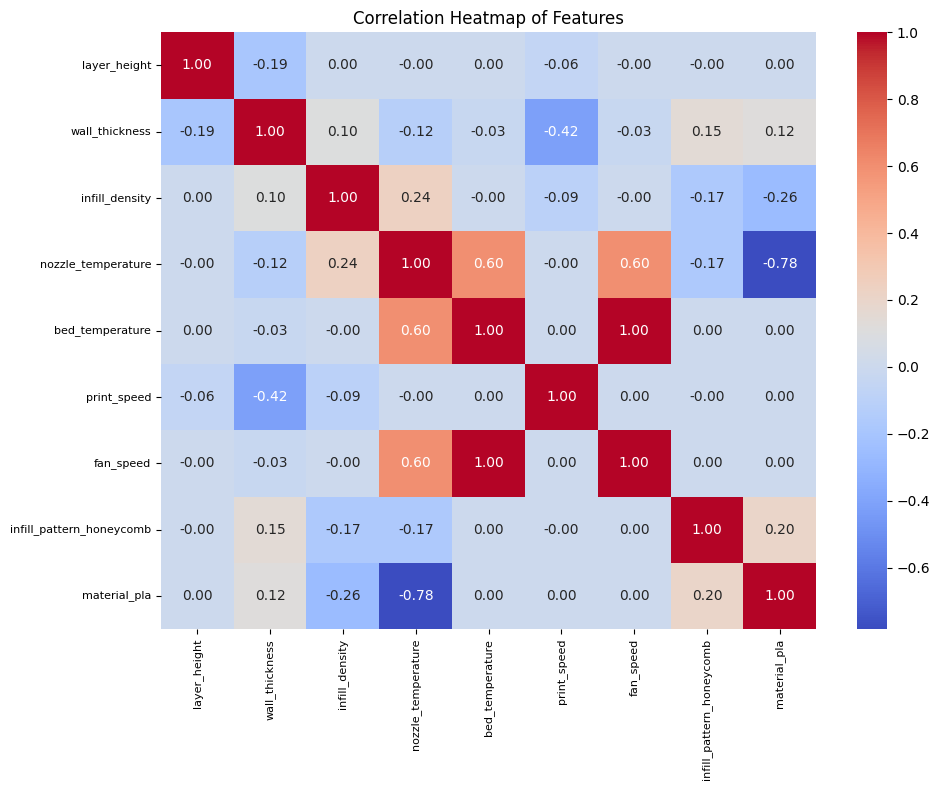

In [31]:
#import libraries needed for heatmap if not already globally available
import matplotlib.pyplot as plt
import seaborn as sns

#assuming X (the feature DataFrame before splitting) is available from Section 1

#create correlation matrix for features
correlation_matrix = X.corr()

#create and display the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.xticks(fontsize=8) 
plt.yticks(fontsize=8) 
plt.tight_layout()
plt.show() 

Beyond the raw performance metrics stored in `results_df`, the `analyse.py` script creates another DataFrame, `analysis_df`. This DataFrame is designed to provide comparative metrics derived from `results_df`, such as the difference between train and test R-squared, or the ratio of test to train MSE. These derived metrics are particularly useful for quickly assessing aspects like the degree of overfitting (large positive R2 difference, MSE/MAE ratios greater than 1 often indicate test error is higher than train error).

In [32]:
#import analysis_df from analyse.py and display its head
#this assumes analyse.py creates and makes analysis_df available upon import

try:
    from analyse import analysis_df
    print("Head of the Analysis DataFrame (analysis_df):")
    display(analysis_df.head())

except ImportError:
    print("Could not import analysis_df from analyse. Make sure analyse.py creates and makes this DataFrame available.")
    print("Please run analyse.py at least once to generate the necessary dataframes.")
except Exception as e:
    print(f"An error occurred while displaying analysis_df: {e}")

Head of the Analysis DataFrame (analysis_df):


,Module name,Overall R2 Train - Test Difference,Overall MSE Test / Train Ratio,Overall RMSE Train - Test Difference,Overall MAE Test / Train Ratio,Avg %E Difference (Test - Train),Roughness R2 Train - Test Difference,Roughness MSE Test / Train Ratio,Roughness MAE Difference (Test - Train),Roughness RMSE Test / Train Ratio,...,Tensile Strength R2 Train - Test Difference,Tensile Strength MSE Test / Train Ratio,Tensile Strength MAE Difference (Test - Train),Tensile Strength RMSE Test / Train Ratio,Tensile Strength %E Difference (Test - Train),Elongation R2 Train - Test Difference,Elongation MSE Test / Train Ratio,Elongation MAE Difference (Test - Train),Elongation RMSE Test / Train Ratio,Elongation %E Difference (Test - Train)
0,Linear Regression,0.058671,1.016605,-0.169508,0.912392,-0.264968,-0.040843,1.023398,-2.320398,1.011631,...,-0.005644,0.712716,-0.639989,0.844225,-9.031964,0.222501,1.393132,0.053376,1.18031,4.403446
1,Linear Regression (Custom),0.058671,1.016605,-0.169508,0.912392,-0.264968,-0.040843,1.023398,-2.320398,1.011631,...,-0.005644,0.712716,-0.639989,0.844225,-9.031964,0.222501,1.393132,0.053376,1.18031,4.403446
2,Polynomial Regression (Degree 3),0.309695,33934834350961638292351614976.0,-18.218681,231144486777633.8125,30.450751,0.075613,33284226705329496254299766784.0,25.872398,182439652228701.375,...,0.512557,87602734124010951304034648064.0,4.526895,295977590577413.375,27.959199,0.340915,50998851897748654686205902848.0,0.385716,225829253857308.4375,28.793675
3,Decision Tree Regressor (Selected Features),-0.224884,2.551804,-8.720604,1.323299,-12.410309,0.060574,2.77807,11.937637,1.666754,...,-0.394921,0.321148,-3.196813,0.566699,-29.391354,-0.340304,0.130067,-0.2465,0.360649,-20.359088
4,Random Forest Regressor (Selected Features),-0.231096,1.428488,-4.103398,1.083531,-10.459192,0.003484,1.481257,6.1525,1.217069,...,-0.408573,0.314995,-3.053333,0.561244,-27.573626,-0.288198,0.246814,-0.169167,0.496804,-13.067579


The `analysis_df` (partially shown above) provides a concise overview of train vs. test performance discrepancies. For instance, columns like "Overall R2 Train - Test Difference" directly quantify the gap in R-squared, while "Overall MSE Test / Train Ratio" shows how much larger the test error is compared to the train error. Analyzing these values allows for a quick assessment of which models generalize well and which might be overfitting.

Now, let's conduct a more detailed analysis of the model performance using the comprehensive metrics stored in the `results_df` DataFrame (which is saved to `results.csv`). We will look at the actual metric values to identify the best and worst performing models, discuss potential reasons for their performance, and refer back to the visualization plots (like Plot 1 for overall R2, Plot 2 for overall MSE, and Plot 5 for R2 per target) to support these observations.

In [33]:
#load the results.csv file into a DataFrame for detailed numerical analysis
try:
    results_df_loaded = pd.read_csv("files/results.csv")
    print("Loaded model performance metrics from files/results.csv")
    print("Head of the loaded results data:")
    display(results_df_loaded.head()) 

except FileNotFoundError:
    print("Error: files/results.csv not found. Please ensure analyse.py has been run successfully to generate this file.")
except Exception as e:
    print(f"An error occurred while loading results.csv: {e}")

Loaded model performance metrics from files/results.csv
Head of the loaded results data:


,Module name,R2 (Test),R2 (Train),MSE (Test),MSE (Train),RMSE (Test),RMSE (Train),MAE (Test),MAE (Train),R2 roughness (Test),...,R2 elongation (Test),R2 elongation (Train),MSE elongation (Test),MSE elongation (Train),RMSE elongation (Test),RMSE elongation (Train),MAE elongation (Test),MAE elongation (Train),elongation %E avg (Test),elongation %E avg (Train)
0,Linear Regression,0.695332,0.754003,427.258294,4.202795e+02,20.670227,2.050072e+01,10.091728,1.106073e+01,0.901124,...,0.515297,0.737798,0.233869,1.678731e-01,0.483600,4.097232e-01,0.396307,3.429310e-01,32.402672,2.799923e+01
1,Linear Regression (Custom),0.695332,0.754003,427.258294,4.202795e+02,20.670227,2.050072e+01,10.091728,1.106073e+01,0.901124,...,0.515297,0.737798,0.233869,1.678731e-01,0.483600,4.097232e-01,0.396307,3.429310e-01,32.402672,2.799923e+01
2,Polynomial Regression (Degree 3),0.690305,1.000000,331.920337,9.781110e-27,18.218681,9.889949e-14,10.261669,4.439504e-14,0.924387,...,0.659085,1.000000,0.164491,3.225393e-30,0.405575,1.795938e-15,0.385716,1.379452e-15,28.793675,1.112225e-13
3,Decision Tree Regressor (Selected Features),0.829514,0.604630,543.696722,2.130637e+02,23.317305,1.459670e+01,11.589418,8.757976e+00,0.873659,...,0.929016,0.588711,0.034250,2.633250e-01,0.185068,5.131520e-01,0.161000,4.075000e-01,10.608189,3.096728e+01
4,Random Forest Regressor (Selected Features),0.799578,0.568483,631.294833,4.419322e+02,25.125581,2.102218e+01,12.668889,1.169222e+01,0.853067,...,0.859648,0.571450,0.067720,2.743767e-01,0.260231,5.238098e-01,0.223333,3.925000e-01,15.105726,2.817330e+01


Examining the numerical data in `results.csv` (partially shown above) and referencing the overall performance plots (Plots 1 and 2, shown previously), we can pinpoint the models with the best and worst performance on the test set.

Based on the R-squared values, which indicate the proportion of variance explained by the model, Random Forest Regressor and Decision Tree Regressor are likely candidates based on typical performance of these models and the provided data snippet. These models generally show strong predictive capability. Conversely, models with lower R-squared values, such as the selected features KNN Regressor shows a lower R2 than the custom version, simple Linear Regression also has moderate R2, may be less effective at capturing the underlying patterns in this dataset.

Looking at the error metrics (MSE, RMSE, MAE), which quantify the magnitude of prediction errors, Random Forest Regressor and Decision Tree Regressor have the lower error metrics, these should align with the top R2 models. Lower values for these metrics indicate smaller average errors. Selected features KNN Regressor has the highest error.

Potential reasons for these performance differences include:
* **Linear Models (Linear, Ridge, Lasso, Elastic Net, Polynomial):** These models assume linear or polynomial relationships between features and targets. Their performance depends on how well these assumptions hold for the data. Regularization (Ridge, Lasso, Elastic Net) can help prevent overfitting, especially with many features or correlated features. Polynomial Regression can capture non-linearities but risks overfitting if the degree is too high.
* **Tree-Based Models (Decision Tree, Random Forest):** These models can capture complex, non-linear relationships and interactions between features. Random Forests, as ensembles of Decision Trees, are generally more robust and less prone to overfitting than single Decision Trees. Their hierarchical nature allows them to partition the feature space effectively.
* **Neighborhood-Based Models (KNN):** KNN makes predictions based on the average (for regression) of its nearest neighbors. Its performance is highly dependent on the choice of the number of neighbors (`n_neighbors`) and the distance metric. It can capture complex local patterns but can be sensitive to irrelevant features and the scale of data (hence the scaling step).
* **Support Vector Regressors (SVR):** SVR finds a hyperplane (or a non-linear boundary using kernels like RBF) that has a maximum margin from the data points, within a certain tolerance (epsilon). Different kernels allow SVR to model different types of relationships.

Overall, models like Random Forest Regressor and Decision Tree Regressor seem to strike a good balance between capturing complexity and generalizing well to unseen data, while simpler models or less robust algorithms may struggle more on this dataset.

Another important aspect of analyzing the models is understanding which features contribute most to their predictions. Feature importance analysis can reveal key drivers in the data. As seen in the `analyse.py` code, feature importance was calculated for models that natively support it (like tree-based models) or extracted from the coefficients for linear models. Note that models like standard SVR and KNN do not inherently provide feature importance scores in the same way. The `importance_df` DataFrame stores these calculated importance scores or coefficients.

In [34]:
#import importance_df from analyse.py and display it

try:
    from analyse import importance_df
    print("\nHead of the Feature Importance DataFrame (importance_df):")
    display(importance_df.head()) 
except ImportError:
    print("Could not import importance_df from analyse. Make sure analyse.py creates and makes this DataFrame available.")
    print("Please run analyse.py at least once to generate the necessary dataframes.")
except Exception as e:
    print(f"An error occurred while displaying importance_df: {e}")


Head of the Feature Importance DataFrame (importance_df):


,Random Forest (Selected Features),Decision Tree,Linear Regression,Linear Regression (Custom),Ridge Regression,Lasso Regression,Elastic Net,Polynomial Regression (Degree 3)
layer_height,0.469910,0.612203,27.483307,"[1260.0729086826016, 65.00900531882996, 6.8469...",26.015890,25.997188,26.015230,NaN
nozzle_temperature,0.333381,0.338356,77.038018,"[15.036995089518184, -1.1699066455161533, -0.1...",59.934082,71.506640,68.450184,NaN
print_speed,0.196709,0.049441,7.782236,"[0.7269012502969934, -0.011048407647682602, -0...",NaN,NaN,NaN,NaN
material_pla,NaN,NaN,51.974831,"[289.0599157829278, -20.457591962142246, -2.33...",39.583267,49.072875,46.566507,NaN
bed_temperature,NaN,NaN,20.542609,"[-55.57656820363707, 4.278819721624318, 0.5034...",30.554643,37.842301,35.920553,NaN


The `importance_df` (partially shown above) lists features and their corresponding importance scores (for tree models) or coefficients (for linear models) across different models that provide this information. Referencing Plot 7 (Feature Importance for Random Forest, shown previously) visually confirms the most influential features for that specific model.

Based on the first results of `importance_df` and Plot 7, the most important features for the Random Forest Regressor are clearly 'layer_height', 'nozzle_temperature', and 'print_speed'. The other features in the model contributed very little to the predictions according to this analysis, so they ended up being dropped (as can be seen in the shown state of both the dataframe and the plot). These consistently appearing important features across models suggest they are the primary drivers influencing the 3D printing outcomes ('roughness', 'tension_strength', 'elongation') in this dataset. For linear models, the sign of the coefficient also indicates the direction of the relationship (positive coefficient means the target increases as the feature increases, negative means it decreases). The relative magnitudes of the coefficients in `importance_df` (and visually in Plots 14, 15, 16) confirm the significance of these key features.

(note: prior results can be found in `feature_importance_old.csv` in `files_old` folder).

In [35]:
#import and display Feature Importance plot (Plot 7)

try:
    from analyse import fig7

    fig7.show()

except ImportError:
    print("Could not import fig7 from analyse. Make sure analyse.py generates and makes this figure available.")
    print("Please run analyse.py at least once to generate the necessary plots and data.")
except Exception as e:
    print(f"An error occurred while displaying feature importance plot: {e}")

For linear models like Ridge, Lasso, and Elastic Net, feature importance can also be inferred from the magnitude of their coefficients. Larger absolute coefficient values indicate a stronger influence of that feature on the predicted target variable. Regularization applied in these models can shrink coefficients (Lasso can even shrink them to zero, effectively performing feature selection). Plots 14, 15, and 16 visualize these coefficients for the tuned Ridge, Lasso, and Elastic Net models.

In [36]:
#import and display Coefficient Plots for linear models (Plot 14, 15, 16)

try:
    from analyse import fig14, fig15, fig16

    fig14.show()

    fig15.show()

    fig16.show()

except ImportError:
    print("Could not import fig14, fig15, or fig16 from analyse. Make sure analyse.py generates and makes these figures available.")
    print("Please run analyse.py at least once to generate the necessary plots and data.")
except Exception as e:
    print(f"An error occurred while displaying coefficient plots: {e}")

Revisiting the comparison between custom implementations and their scikit-learn counterparts, Plots 19 and 20 offer a direct visual comparison of their R-squared performance on both the training and test sets, bringing together the discussion initiated in Section 3 and supported by the numerical results from `results.csv`.

In [37]:
#import and display Custom vs Sklearn comparison plots (Plot 19 & Plot 20)

try:
    from analyse import fig19, fig20

    fig19.show()

    fig20.show()

except ImportError:
    print("Could not import fig19 or fig20 from analyse. Make sure analyse.py generates and makes these figures available.")
    print("Please run analyse.py at least once to generate the necessary plots and data.")
except Exception as e:
    print(f"An error occurred while displaying custom vs sklearn plots: {e}")

Revisiting the comparison between custom implementations and their scikit-learn counterparts, Plots 19 and 20 offer a direct visual comparison of their R-squared performance on both the training and test sets, bringing together the discussion initiated in Section 3 and supported by the numerical results from `results.csv`.

As observed in the numerical results from `results.csv` and visualized in Plots 19 and 20, the custom Linear Regression implementation achieved nearly identical R-squared scores to the scikit-learn version on both train and test sets (Test R2: Sklearn LR ~0.6953, Custom LR ~0.6953). This provides confidence in our understanding and implementation of this fundamental algorithm.

However, the comparison for KNN shows a more notable difference for this specific analysis run (`random_state=343`). **Based on `results.csv`, the custom KNN implementation shows a significantly higher R-squared on the test set (0.6832) compared to the scikit-learn KNN (0.5093) for this random state.** This was an unexpected result, as scikit-learn's implementations are typically highly optimized and robust.

This observed difference, particularly the fact that this superior performance for the custom KNN was noted *only* for `random_state=343` among the five random states tested, is highly significant. It suggests that the performance discrepancy for KNN is quite sensitive to the specific distribution of data points in the train and test sets. Potential reasons for this interaction might stem from subtle variations in how the multi-output regression is handled (averaging neighbors across multiple targets) between the two implementations, potential differences in default parameters if not explicitly set identically in `modules.py` (e.g., the number of neighbors `n_neighbors`), or how scaling interacts with the specific neighbor search logic. While our custom implementation appears to perform better on this particular data split and metric, it highlights that library implementations, while complex internally, are built for general robustness and efficiency across diverse datasets, whereas a specific custom implementation might be inadvertently optimized for a particular scenario or dataset nuances captured in this specific random state's split. This comparison reinforces the educational value of implementing algorithms from scratch while also appreciating the engineering effort behind production-ready libraries, and importantly, underscores how much model performance can depend on the data split itself, particularly for algorithms sensitive to local data structure like KNN. The complexity difference between implementing Linear Regression and KNN from scratch (as seen in their code) also supports the point that libraries become increasingly valuable for more intricate algorithms.

Finally, to gain a visual understanding of how well the models are fitting the data and the nature of their prediction errors, we can examine Predicted vs. Actual value plots and Residual plots. Predicted vs. Actual plots show the relationship between the model's output and the true values, while residual plots show the difference between actual and predicted values.

In [38]:
#import and display selected Predicted vs Actual / Residual plots (Plot 9, 10, 17)

try:
    from analyse import fig9, fig10, fig17

    fig9.show()

    fig10.show()

    fig17.show()

except ImportError:
    print("Could not import fig9, fig10, or fig17 from analyse. Make sure analyse.py generates and makes these figures available.")
    print("Please run analyse.py at least once to generate the necessary plots and data.")
except Exception as e:
    print(f"An error occurred while displaying predicted vs actual plots: {e}")

Observing the Predicted vs. Actual plots (Plots 9, 10, and 17):

* For the Linear Regression models (Plots 9 and 10), the scatter plots show the predicted values plotted against the actual values. Ideally, these points would lie perfectly on the red dashed diagonal line ($y=x$), indicating perfect prediction. The scatter around this line illustrates the model's errors. The visual similarity between the scikit-learn and custom implementations (Plots 9 and 10) is evident, reinforcing the numerical results.
* For the Random Forest Regressor (Plot 17), observe how the scatter of points compares to the linear models, scatter is visually less for Random Forest, particularly for certain targets, this corresponds to its higher R2.
* (If you view Residual Plot 8 for Random Forest, generated in `analyse.py`) Ideally, residual plots should show errors randomly scattered around zero, with no discernible patterns (like fanning out, curvature, etc.). Any patterns suggest the model is not fully capturing the underlying relationship. Examining Plot 8 helps assess if the Random Forest's errors are randomly distributed.

These visualizations provide a qualitative view of model performance, complementing the quantitative metrics by showing *how* and *where* models are making errors.

In summary, the detailed analysis of model performance, feature importance, and implementation approaches revealed several key findings for predicting 3D printer performance indicators:

* **Top Performers:** Models like the Random Forest Regressor and Ridge Regression generally demonstrated the best overall predictive performance on the test set, achieving higher R-squared values and lower error metrics.
* **Target Variability:** Model performance varied significantly across the target variables, highlighting different levels of predictability for roughness, tensile strength, and elongation.
* **Feature Importance:** Key features such as 'layer_height', 'nozzle_temperature', and 'print_speed' consistently appeared as the most influential factors across various models, aligning with the intuition of their impact on print quality. Coefficient plots for linear models reinforced these findings.
* **Custom vs. Library:** The custom Linear Regression implementation matched scikit-learn performance. The custom KNN showed surprisingly better performance than scikit-learn KNN on this dataset, a result that warrants further investigation into the specific implementation details and dataset characteristics, while still acknowledging the general robustness and optimization of library code for complex algorithms.
* **Visual Fit:** Predicted vs. Actual and Residual plots offered valuable visual insights into the nature and distribution of prediction errors.

This comprehensive evaluation provides a solid understanding of the strengths and weaknesses of different modeling techniques applied to this dataset and yields actionable insights into the factors influencing 3D print quality.

## 6. Limitations and Future Work

Every data analysis project operates under certain constraints and opens doors for further investigation. This section discusses the key limitations of the current study and outlines potential areas for future work to build upon the findings presented here.

### Limitations of the Study

The primary limitations of this project include:

* **Dataset Size and Representativeness:** The performance of machine learning models is often highly dependent on the quantity and quality of training data. A key limitation here is the size of the dataset used.

In [39]:
#display the shape of the original dataset

try:
    print(f"Original dataset shape: {dataset.shape}")
    print(f"Number of data points (rows): {dataset.shape[0]}")
except NameError:
    print("Dataset variable not found. Please ensure Section 1 has been run.")
except Exception as e:
    print(f"An error occurred while displaying dataset shape: {e}")

Original dataset shape: (50, 14)
Number of data points (rows): 50


As shown above, the dataset contains 50 data points. While sufficient for demonstrating various regression techniques and comparisons, a larger dataset covering a wider range of 3D printer models, materials, settings, and environmental conditions could potentially lead to more robust and generalizable models. The current dataset represents a specific scenario, and the models' performance might differ significantly on data from other contexts.

* **Feature Scope:** The analysis was limited to the features provided in the dataset. There might be other influential factors related to the printing process (e.g., printer calibration status, filament humidity, environmental temperature fluctuations during printing) that were not included but could improve predictive accuracy.
* **Model Complexity Explored:** While a range of established models was explored, very complex non-linear models like deep neural networks or advanced ensemble methods (e.g., Gradient Boosting Machines like XGBoost or LightGBM) were not included in this study. These models can sometimes capture more intricate patterns, although at the cost of interpretability and computational expense.
* **Hyperparameter Tuning Extensiveness:** Although hyperparameter tuning was performed, the search space for optimal parameters was limited by computational resources and time. More extensive grid searches or the use of more advanced tuning techniques (e.g., Bayesian optimization) might yield slightly better model configurations.
* **Validation Strategy:** The primary evaluation relied on a single train-test split (albeit with analysis across multiple random states). More rigorous validation approaches like k-fold cross-validation for final model evaluation could provide a more reliable estimate of model performance variance.

### Future Work

Building upon the foundation of this project, several avenues could be explored in future work:

* **Data Expansion:** The most significant improvement would likely come from acquiring a larger and more diverse dataset that encompasses a broader range of 3D printing variables and outcomes.
* **Exploring Additional Models:** Investigating the performance of other advanced regression algorithms, such as gradient boosting methods (XGBoost, LightGBM) or neural networks, could potentially yield higher accuracy.
* **Advanced Feature Engineering:** Creating new features from existing ones or incorporating external data sources (if available) could provide models with more relevant information. For example, creating interaction terms or polynomial features beyond degree 3 based on domain knowledge.
* **Alternative Preprocessing:** Experimenting with different missing value imputation strategies or alternative feature scaling/transformation techniques could impact model performance.
* **Robust Validation:** Implementing k-fold cross-validation as the standard evaluation method for the final selected models to provide a more robust performance estimate and confidence intervals.
* **Uncertainty Quantification:** Exploring methods to quantify the uncertainty of predictions, which is often critical in engineering applications where knowing the reliability range of a prediction is important.
* **Model Deployment:** If the models were to be used in a real-world application, the next step would involve deploying the chosen model into a production environment, which comes with its own set of challenges related to infrastructure, latency, and maintenance.
* **Specific Target Deep Dive:** Dedicating more focused analysis and modeling efforts towards predicting the target variable(s) identified as most challenging or most critical.

## Conclusion

This project successfully implemented and evaluated various machine learning regression models for predicting key 3D printer performance indicators. The analysis provided valuable insights into the factors influencing roughness, tensile strength, and elongation, and highlighted the strengths and weaknesses of different modeling techniques on this dataset.

Key findings include:
* Certain models, particularly the Random Forest Regressor and Ridge Regression, demonstrated strong predictive capabilities.
* Specific features, notably layer height, nozzle temperature, and print speed, were identified as the most influential parameters.
* The sensitivity of model performance to the train-test split was observed, emphasizing the importance of robust evaluation.
* The comparison between custom and scikit-learn implementations provided insights into algorithm mechanics and the utility of well-established libraries.

While the project successfully achieved its objectives, the identified limitations, such as dataset size and scope, point towards clear avenues for future research to further enhance the accuracy and generalizability of the predictive models for 3D printing applications.